# Tahap Pemodelan: Pelatihan SVM Berbasis FastText (Full Visualisasi)

Dokumen ini memuat langkah-langkah komprehensif dalam melatih model klasifikasi **Support Vector Machine (SVM)** menggunakan ruang vektor **FastText**. Selaras dengan tahapan Pra-Pemrosesan sebelumnya, *notebook* ini dilengkapi dengan visualisasi komputasi matematis di setiap tahapannya guna memperkuat bukti penelitian.

Tahapan metodologi yang dilakukan meliputi:
1. **Membaca Dataset Final** (+ Visualisasi Proporsi Kelas)
2. **Feature Extraction (FastText)** (+ Visualisasi PCA Ruang Vektor Teks)
3. **Train-Test Split** (+ Visualisasi Proporsi Pembagian)
4. **Hyperparameter Tuning (GridSearchCV)** (+ Visualisasi Komparasi Model)
5. **Evaluasi Akademik** (+ Visualisasi Metrik Klasifikasi)
6. **Visualisasi Confusion Matrix**
7. **Ekspor Model Akhir**

In [1]:
import pandas as pd
import numpy as np
import fasttext
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.decomposition import PCA

from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import re

import warnings
warnings.filterwarnings('ignore')

# Standarisasi Konfigurasi Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Membaca Dataset Final
Memuat hasil data yang sudah disiapkan dan diseimbangkan (*undersampled*) pada modul Pra-Pemrosesan.

=== TAHAP 1: MEMUAT DATASET ===
[LOG] Total observasi siap latih: 1544 baris.


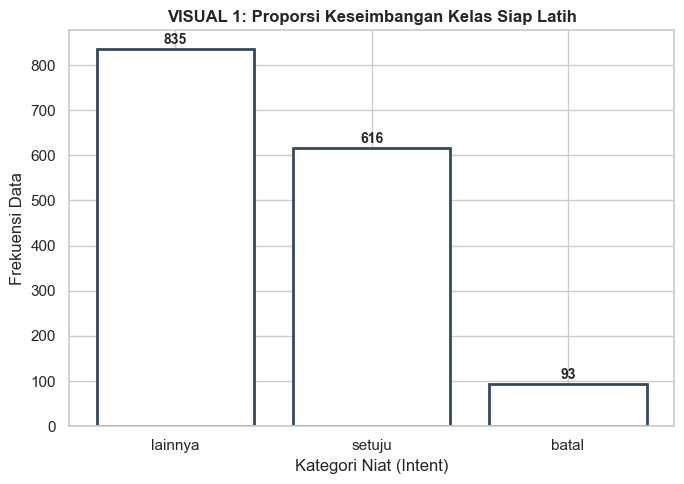

In [2]:
print("=== TAHAP 1: MEMUAT DATASET ===")
file_dataset = 'data/dataset_siap_latih_final.csv'
df = pd.read_csv(file_dataset)

# Memastikan tidak ada nilai kosong
df = df.dropna(subset=['clean_text', 'intent']).copy()

print(f"[LOG] Total observasi siap latih: {len(df)} baris.")

# VISUALISASI 1: Cek Keseimbangan Kelas Final
intent_counts = df['intent'].value_counts()
plt.figure(figsize=(7, 5))
bars = plt.bar(intent_counts.index, intent_counts.values, facecolor='white', edgecolor='#34495e', linewidth=2)
plt.title('VISUAL 1: Proporsi Keseimbangan Kelas Siap Latih', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Niat (Intent)')
plt.ylabel('Frekuensi Data')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Ekstraksi Fitur (FastText Word Embeddings)
Mengubah teks menjadi ruang vektor matematis 300 dimensi. Untuk membuktikan secara visual bahwa representasi FastText bekerja dengan baik dalam memisahkan makna kata, kita akan mereduksi 300 dimensi tersebut menjadi 2 dimensi dengan algoritma PCA.

=== TAHAP 2: EKSTRAKSI FITUR FASTTEXT ===
[LOG] Memuat FastText pre-trained model (cc.id.300.bin)... 
[LOG] Ekstraksi vektor kalimat...
[LOG] Mereduksi 300 Dimensi FastText menjadi 2D untuk visualisasi...


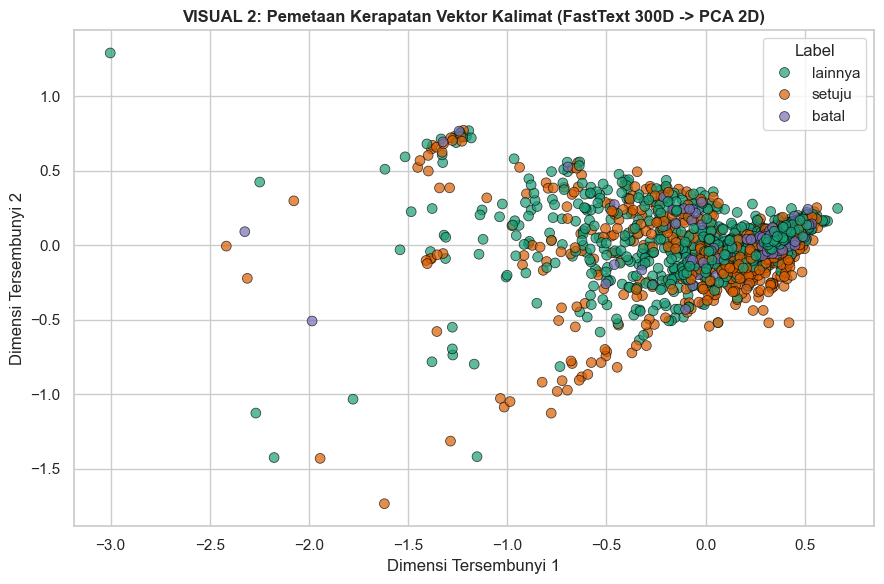

In [3]:
print("=== TAHAP 2: EKSTRAKSI FITUR FASTTEXT ===")
print("[LOG] Memuat FastText pre-trained model (cc.id.300.bin)... ")
if not os.path.exists('models/cc.id.300.bin'):
    raise FileNotFoundError("File model cc.id.300.bin tidak ditemukan!")
    
ft_model = fasttext.load_model('models/cc.id.300.bin')
print("[LOG] Ekstraksi vektor kalimat...")

def get_sentence_vector(text, ft_model):
    words = str(text).split()
    if not words:
        return np.zeros(ft_model.get_dimension())
    word_vectors = [ft_model.get_word_vector(w) for w in words]
    return np.mean(word_vectors, axis=0)

X = np.array([get_sentence_vector(t, ft_model) for t in df['clean_text']])
y = df['intent'].values

# VISUALISASI 2: Visualisasi Ruang Vektor (PCA 2D)
print("[LOG] Mereduksi 300 Dimensi FastText menjadi 2D untuk visualisasi...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Label': y})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Label', palette='Dark2', s=50, edgecolor='black', alpha=0.7)
plt.title('VISUAL 2: Pemetaan Kerapatan Vektor Kalimat (FastText 300D -> PCA 2D)', fontsize=12, fontweight='bold')
plt.xlabel('Dimensi Tersembunyi 1')
plt.ylabel('Dimensi Tersembunyi 2')
plt.tight_layout()
plt.show()

## 3. Pembagian Data (*Train-Test Split*)
Membagi proporsi 80% data latih dan 20% data uji menggunakan teknik stratifikasi untuk menjaga komposisi kelas tetap proporsional.

=== TAHAP 3: PEMBAGIAN DATA (80:20) ===


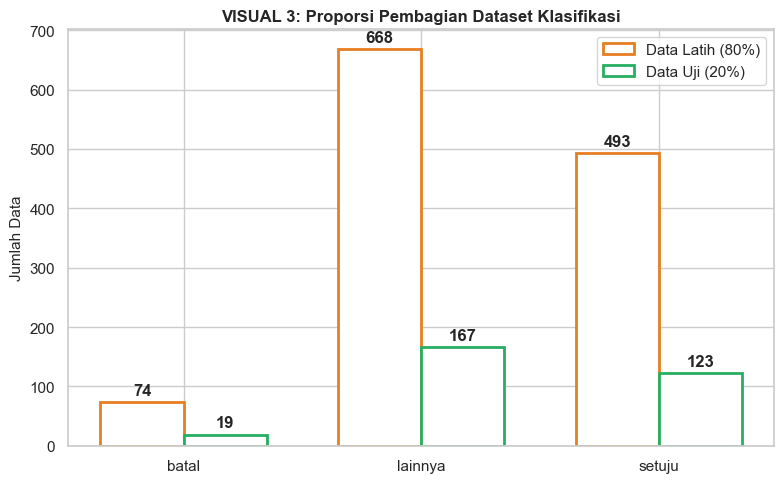

In [4]:
print("=== TAHAP 3: PEMBAGIAN DATA (80:20) ===")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menyusun data untuk visualisasi
labels, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x_pos - width/2, train_counts, width, label='Data Latih (80%)', facecolor='white', edgecolor='#e67e22', linewidth=2)
rects2 = ax.bar(x_pos + width/2, test_counts, width, label='Data Uji (20%)', facecolor='white', edgecolor='#27ae60', linewidth=2)

ax.set_ylabel('Jumlah Data', fontsize=11)
ax.set_title('VISUAL 3: Proporsi Pembagian Dataset Klasifikasi', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

## 4. Pelatihan Model & *Hyperparameter Tuning*
Mencari konfigurasi model SVM terbaik melalui *Cross Validation*.

=== TAHAP 4: GRIDSEARCH & TRAINING ===
[LOG] Memulai komputasi parameter (harap tunggu)...

[HASIL] Parameter Paling Optimal: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}


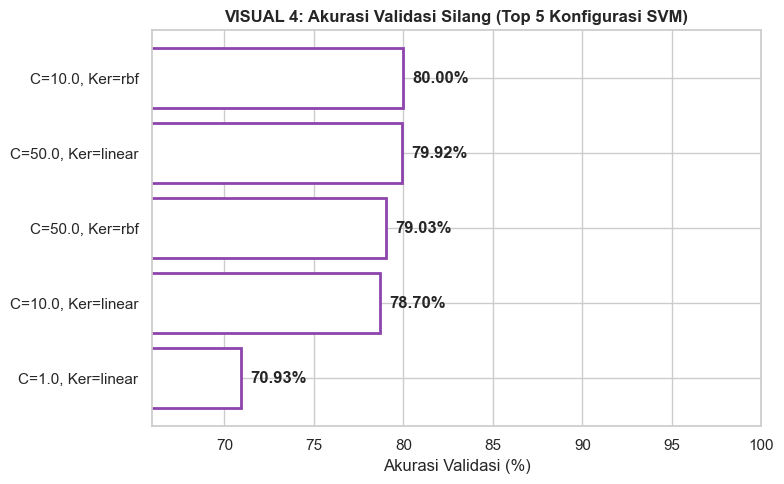

In [5]:
print("=== TAHAP 4: GRIDSEARCH & TRAINING ===")
param_grid = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)

print("[LOG] Memulai komputasi parameter (harap tunggu)...")
grid_search.fit(X_train, y_train)
best_svm_clf = grid_search.best_estimator_

print(f"\n[HASIL] Parameter Paling Optimal: {grid_search.best_params_}")

# VISUALISASI 4: Kinerja 5 Kombinasi Parameter Teratas
results = pd.DataFrame(grid_search.cv_results_)
top_5_results = results.sort_values(by='mean_test_score', ascending=False).head(5)
model_configs = top_5_results.apply(lambda x: f"C={x['param_C']}, Ker={x['param_kernel']}", axis=1)
scores = top_5_results['mean_test_score'] * 100

plt.figure(figsize=(8, 5))
bars = plt.barh(model_configs[::-1], scores[::-1], facecolor='white', edgecolor='#8e44ad', linewidth=2)
plt.title('VISUAL 4: Akurasi Validasi Silang (Top 5 Konfigurasi SVM)', fontsize=12, fontweight='bold')
plt.xlabel('Akurasi Validasi (%)')
plt.xlim(min(scores)-5, 100)

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.2f}%",
             va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Evaluasi Kinerja Model (*Testing*)
Menguji *Best Estimator* secara langsung pada himpunan Data Uji.

=== TAHAP 5: EVALUASI KINERJA ===
--- Laporan Matriks Klasifikasi ---
              precision    recall  f1-score   support

       batal       0.78      0.74      0.76        19
     lainnya       0.83      0.90      0.86       167
      setuju       0.85      0.75      0.80       123

    accuracy                           0.83       309
   macro avg       0.82      0.80      0.81       309
weighted avg       0.83      0.83      0.83       309



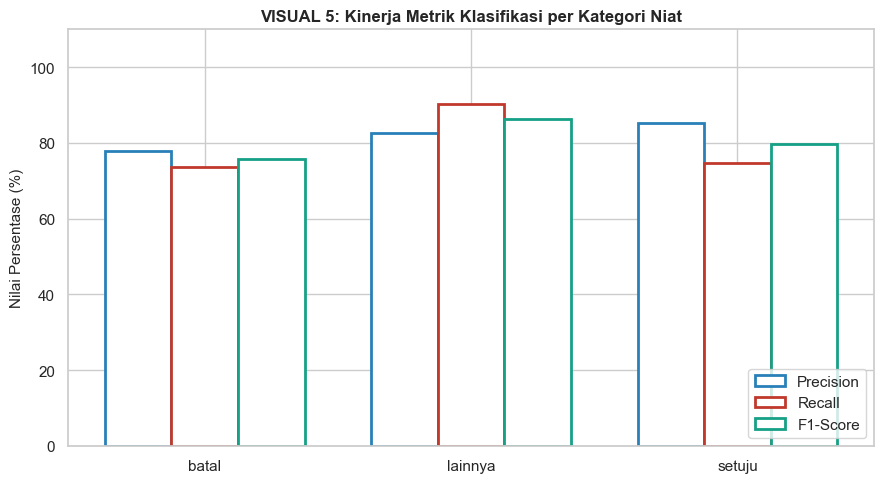

In [6]:
print("=== TAHAP 5: EVALUASI KINERJA ===")
y_pred = best_svm_clf.predict(X_test)

print("--- Laporan Matriks Klasifikasi ---")
print(classification_report(y_test, y_pred))

# VISUALISASI 5: Grafik Presisi, Recall, dan F1-Score
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, labels=labels)

x_pos = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x_pos - width, precision * 100, width, label='Precision', facecolor='white', edgecolor='#2980b9', linewidth=2)
rects2 = ax.bar(x_pos, recall * 100, width, label='Recall', facecolor='white', edgecolor='#c0392b', linewidth=2)
rects3 = ax.bar(x_pos + width, fscore * 100, width, label='F1-Score', facecolor='white', edgecolor='#16a085', linewidth=2)

ax.set_ylabel('Nilai Persentase (%)', fontsize=11)
ax.set_title('VISUAL 5: Kinerja Metrik Klasifikasi per Kategori Niat', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylim(0, 110)
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## 6. Visualisasi *Confusion Matrix*
Menampilkan kepadatan prediksi di area diagonal (yang menandakan prediksi tepat) berbalut desain palet biru monokromatik.

=== TAHAP 6: CONFUSION MATRIX ===


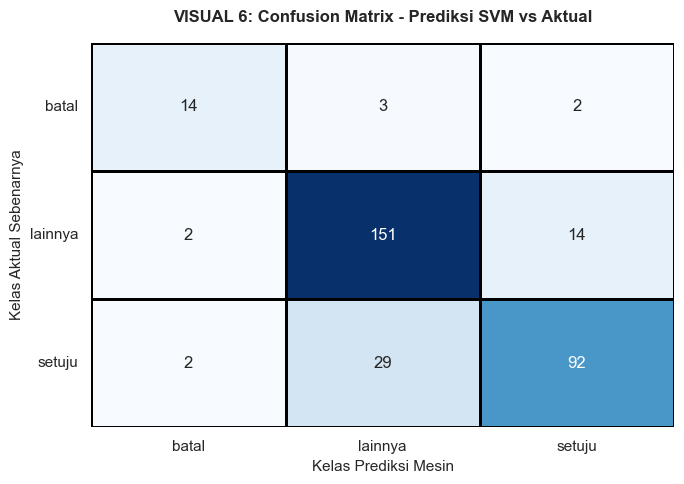

In [7]:
print("=== TAHAP 6: CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, 
            cbar=False, linewidths=1, linecolor='black')
plt.title('VISUAL 6: Confusion Matrix - Prediksi SVM vs Aktual', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kelas Prediksi Mesin', fontsize=11)
plt.ylabel('Kelas Aktual Sebenarnya', fontsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6.5 Validasi Silang (*K-Fold Cross Validation*)
Untuk membuktikan bahwa akurasi model tidak terjadi karena faktor kebetulan dalam pembagian data latih dan uji, kita melakukan uji validasi silang (Stratified 5-Fold) ke seluruh matriks fitur.

=== TAHAP 6.5: K-FOLD CROSS VALIDATION ===
Skor Akurasi tiap Lipatan (Fold): [0.79352227 0.78947368 0.81781377 0.80161943 0.77732794]
Rata-rata Akurasi Validasi Silang: 0.7960 (+/- 0.0269)


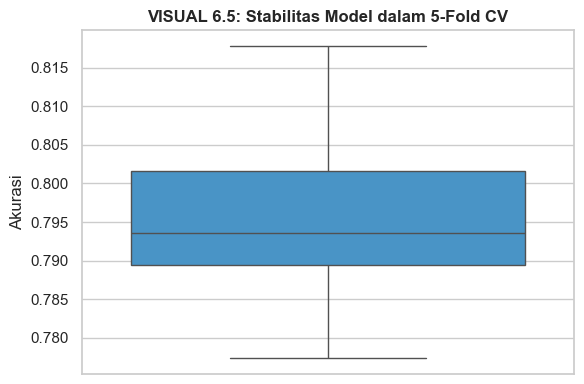

In [8]:
print("=== TAHAP 6.5: K-FOLD CROSS VALIDATION ===")
# Melakukan 5-Fold Cross Validation menggunakan model terbaik
cv_scores = cross_val_score(best_svm_clf, X_train, y_train, cv=5, scoring='accuracy')

print(f"Skor Akurasi tiap Lipatan (Fold): {cv_scores}")
print(f"Rata-rata Akurasi Validasi Silang: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualisasi Boxplot untuk melihat sebaran akurasi
plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='#3498db')
plt.title('VISUAL 6.5: Stabilitas Model dalam 5-Fold CV', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi')
plt.tight_layout()
plt.show()

## 6.6 Kurva Pembelajaran (*Learning Curve*)
Visualisasi ini sangat krusial dalam skripsi Machine Learning untuk membuktikan bahwa model tidak mengalami *Overfitting* maupun *Underfitting*.

=== TAHAP 6.6: LEARNING CURVE ===


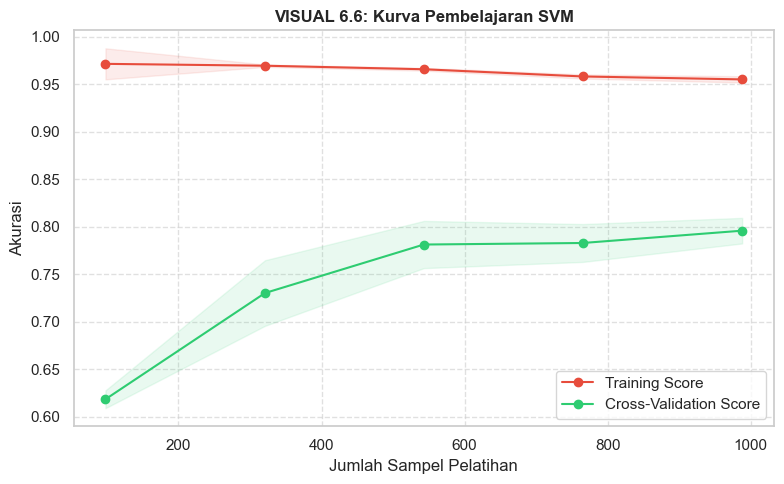

In [9]:
print("=== TAHAP 6.6: LEARNING CURVE ===")
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_clf, X_train, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="#e74c3c", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="#2ecc71", label="Cross-Validation Score")

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="#e74c3c")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="#2ecc71")

plt.title('VISUAL 6.6: Kurva Pembelajaran SVM', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Sampel Pelatihan')
plt.ylabel('Akurasi')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 6.7 Kurva ROC-AUC Multi-Kelas
Mengevaluasi sensitivitas model dalam membedakan masing-masing kelas (Setuju, Batal, Lainnya) dengan menggunakan pendekatan *One-vs-Rest* (OvR).

=== TAHAP 6.7: ROC-AUC CURVE ===


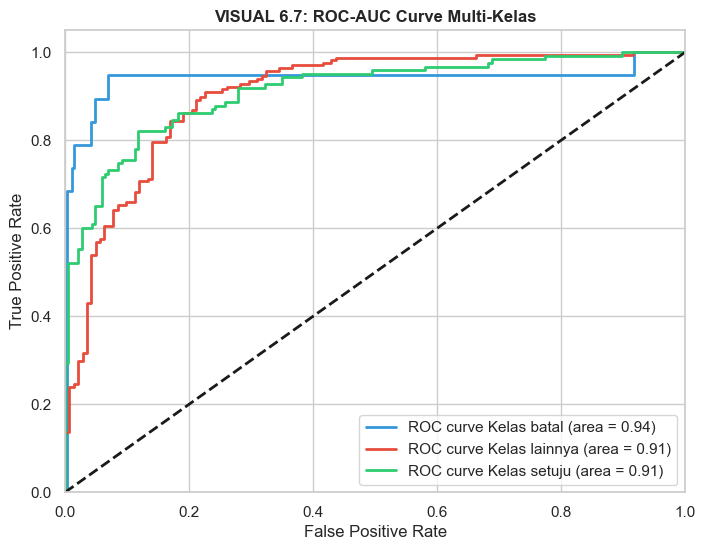

In [10]:
print("=== TAHAP 6.7: ROC-AUC CURVE ===")
# Mengubah label teks menjadi bentuk biner (One-vs-Rest)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Memprediksi probabilitas tiap kelas
y_score = best_svm_clf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = ['#3498db', '#e74c3c', '#2ecc71']
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve Kelas {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VISUAL 6.7: ROC-AUC Curve Multi-Kelas', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

## BAB VIII: Simulasi Pengujian Langsung (*Live Testing*)
Pada tahap ini, kita dapat memasukkan kalimat teks baru apa saja ke dalam mesin. Model akan mengubahnya ke dalam ruang vektor secara mandiri dan memprediksi niat pelanggan beserta tingkat persentase probabilitasnya.

In [11]:
print("=== BAB VIII: LIVE TESTING ===")

# Fungsi Normalisasi Teks Mandiri
def normalize_live_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def test_model(input_text):
    # 1. Normalisasi
    clean_text = normalize_live_text(input_text)
    
    # 2. Ekstraksi Fitur FastText
    vector = ft_model.get_sentence_vector(clean_text).reshape(1, -1)
    
    # 3. Prediksi dan Probabilitas
    prediction = best_svm_clf.predict(vector)[0]
    probabilities = best_svm_clf.predict_proba(vector)[0]
    
    print(f"Teks Asli      : '{input_text}'")
    print(f"Teks Bersih    : '{clean_text}'")
    print(f"\n> PREDIKSI NIAT: **{prediction.upper()}**")
    
    print("\n> Probabilitas Tiap Kelas:")
    for cls, prob in zip(best_svm_clf.classes_, probabilities):
        print(f"  - {cls}: {prob*100:.2f}%")

# ==========================================
# GANTI KALIMAT DI BAWAH INI UNTUK UJI COBA
# ==========================================
kalimat_baru = "Aduh bang mahal amat, ndak jadi lah"

print("\n-- MEMULAI UJI COBA --\n")
test_model(kalimat_baru)


=== BAB VIII: LIVE TESTING ===

-- MEMULAI UJI COBA --

Teks Asli      : 'Aduh bang mahal amat, ndak jadi lah'
Teks Bersih    : 'aduh bang mahal amat ndak jadi lah'

> PREDIKSI NIAT: **BATAL**

> Probabilitas Tiap Kelas:
  - batal: 88.47%
  - lainnya: 11.15%
  - setuju: 0.38%


## 7. Ekspor Model
Menyimpan matriks kecerdasan buatan dalam format biner yang padat.

In [12]:
print("=== TAHAP 7: EKSPOR MODEL FINAL ===")
model_filename = 'svm_model_final.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_svm_clf, file)
print(f"✅ BERHASIL: Model klasifikasi cerdas telah disimpan dengan nama '{model_filename}'")

=== TAHAP 7: EKSPOR MODEL FINAL ===
✅ BERHASIL: Model klasifikasi cerdas telah disimpan dengan nama 'svm_model_final.pkl'
